# Finance AI — TAT-QA Research Project
## Financially-Aware, Hallucination-Resistant RAG/QA System
**Author:** Sarthak Salunkhe  
**Benchmark:** TAT-QA (Financial Tables + Text QA)  
**Repo:** https://github.com/sarthakks18/Finance-AI-TATQA

---

## Project Hypothesis
Standalone LLMs are unreliable at financial QA because they:
- Hallucinate numbers and cite wrong evidence
- Leak future information into historical questions
- Don't know when to say 'I can't answer this'

This notebook builds a system **layer by layer**, measuring at every stage whether each layer fixes its targeted failure mode.

## Ablation Ladder
| Week | Stage | Target Failure Mode |
|------|-------|--------------------|
| 1 | Data EDA + Taxonomy | Understand the problem |
| 2 | Data Cleaning | Normalize units, preserve gold evidence |
| 3 | LLM-Only Baseline | Control group |
| 4 | Basic RAG | Wrong cell / wrong paragraph retrieval |
| 5 | Hybrid Retrieval | Exact entity/year matching failures |
| 6 | Deterministic Tools | Arithmetic hallucination |
| 7 | Evidence Verification | Unsupported claims (NLI) |
| 8 | Temporal Firewall | Look-ahead / future leakage |
| 9 | Multi-Agent | Complex multi-step reasoning |
| 10 | Full Ablation Study | Full ladder comparison |
| 11 | Error Analysis | Failure taxonomy + regression tests |
| 12 | Freeze & Package | API, dashboard, final write-up |

## Table of Contents
- [Week 1: EDA & Evaluation Taxonomy](#week-1)
- [Week 2: Data Cleaning & Normalization](#week-2)



---
---
# ═══════════════════════════════════════════
# WEEK 1: TAT-QA EDA & Evaluation Taxonomy
# Sprint: Aug 21-27, 2026
# ═══════════════════════════════════════════


# Week 1: TAT-QA Exploratory Data Analysis & Evaluation Taxonomy
**Project:** Financially-Aware, Hallucination-Resistant RAG/QA System on TAT-QA  
**Sprint:** Aug 21-27, 2026  |  **Author:** Sarthak Salunkhe

---

## Goals
1. Understand TAT-QA schema (tables, paragraphs, questions, gold answers, derivations)
2. Categorize questions: lookup, arithmetic, comparison, multi-span, count, multi-step
3. Audit distributions, scales, missing values
4. Build formal Evaluation Taxonomy (reasoning type -> metrics -> target fix)
5. Export taxonomy + question metadata to CSV

## Finance Background Glossary
| Term | Definition |
|------|------------|
| Revenue | Total income from operations |
| EBITDA | Earnings Before Interest Taxes Depreciation and Amortization |
| Net Income | Revenue minus all expenses |
| Gross Margin | (Revenue - COGS) / Revenue * 100 |
| Operating Margin | Operating Income / Revenue * 100 |
| CapEx | Capital Expenditure on fixed assets |
| Working Capital | Current Assets - Current Liabilities |
| Equity | Assets - Liabilities (shareholders stake) |
| Free Cash Flow | Operating Cash Flow - CapEx |
| EPS | Earnings Per Share |
| Fiscal Year | Companys accounting year (may differ from calendar year) |
| Filing Date | Date a 10-K or 10-Q was submitted to SEC |

---
## 1. Setup & Data Loading

In [1]:
import json
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR   = Path(r'd:\Inevitable\Finance-AI')
RAW_DIR    = BASE_DIR / 'TAT-QA' / 'dataset_raw'
OUTPUT_DIR = BASE_DIR / 'Finance-AI-TATQA'

print('RAW_DIR  exists:', RAW_DIR.exists())
print('OUT_DIR  exists:', OUTPUT_DIR.exists())

RAW_DIR  exists: True
OUT_DIR  exists: True


In [2]:
def load_split(path, name):
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    print(f'  {name:<6}: {len(data):>5} bundles')
    return data

print('Loading...')
train_raw = load_split(RAW_DIR / 'tatqa_dataset_train.json', 'train')
dev_raw   = load_split(RAW_DIR / 'tatqa_dataset_dev.json',   'dev')
test_raw  = load_split(RAW_DIR / 'tatqa_dataset_test.json',  'test')
splits = {'train': train_raw, 'dev': dev_raw, 'test': test_raw}

Loading...
  train :  2201 bundles
  dev   :   278 bundles
  test  :   278 bundles


---
## 2. Schema Inspection

In [3]:
rec = train_raw[0]
print('TOP-LEVEL KEYS:', list(rec.keys()))
print('TABLE KEYS    :', list(rec['table'].keys()))
print('TABLE UID     :', rec['table']['uid'])
print('Table rows (first 3):')
for row in rec['table']['table'][:3]: print(' ', row)
print('PARA KEYS     :', list(rec['paragraphs'][0].keys()))
print('First para    :', rec['paragraphs'][0]['text'][:100], '...')
print('Q KEYS        :', list(rec['questions'][0].keys()))
print()
print('Sample questions (first record):')
for q in rec['questions']:
    print(f"  [{q['answer_type']:12}][{q['answer_from']:12}] scale={q['scale']:8} Q: {q['question'][:70]}")

TOP-LEVEL KEYS: ['table', 'paragraphs', 'questions']
TABLE KEYS    : ['uid', 'table']
TABLE UID     : e78f8b29-6085-43de-b32f-be1a68641be3
Table rows (first 3):
  ['', '2019 %', '2018 %', '2017 %']
  ['Weighted average actuarial assumptions used at 31 March1:', '', '', '']
  ['Rate of inflation2', '2.9', '2.9', '3.0']
PARA KEYS     : ['uid', 'order', 'text']
First para    : Actuarial assumptions ...
Q KEYS        : ['uid', 'order', 'question', 'answer', 'derivation', 'answer_type', 'answer_from', 'rel_paragraphs', 'req_comparison', 'scale']

Sample questions (first record):
  [multi-span  ][table       ] scale=         Q: What does the Weighted average actuarial assumptions consist of?
  [span        ][table       ] scale=percent  Q: How much is the 2019 rate of inflation?
  [span        ][table       ] scale=percent  Q: How much is the 2018 rate of inflation?
  [arithmetic  ][table       ] scale=percent  Q: What is the 2019 average rate of inflation?
  [arithmetic  ][table       ] sca

In [4]:
schema_rows = [
    {'Level':'record',   'Field':'table',         'Type':'dict',      'Notes':'uid + 2-D cell grid'},
    {'Level':'record',   'Field':'paragraphs',    'Type':'list[dict]','Notes':'uid, order, text'},
    {'Level':'record',   'Field':'questions',     'Type':'list[dict]','Notes':'All Qs for this bundle'},
    {'Level':'question', 'Field':'uid',           'Type':'str',       'Notes':'Unique UUID'},
    {'Level':'question', 'Field':'question',      'Type':'str',       'Notes':'Natural-language question'},
    {'Level':'question', 'Field':'answer',        'Type':'list',      'Notes':'Gold answer(s); empty in test'},
    {'Level':'question', 'Field':'derivation',    'Type':'str',       'Notes':'Step expression, e.g. 12.5 - 10.3'},
    {'Level':'question', 'Field':'answer_type',   'Type':'str',       'Notes':'span | multi-span | arithmetic | count'},
    {'Level':'question', 'Field':'answer_from',   'Type':'str',       'Notes':'table | text | table-text'},
    {'Level':'question', 'Field':'rel_paragraphs','Type':'list[int]', 'Notes':'Indices of supporting paragraphs'},
    {'Level':'question', 'Field':'req_comparison','Type':'bool',      'Notes':'True if comparing values'},
    {'Level':'question', 'Field':'scale',         'Type':'str',       'Notes':'percent|thousand|million|billion|empty'},
]
print('TAT-QA Schema Reference Card')
display(pd.DataFrame(schema_rows))

TAT-QA Schema Reference Card


,Level,Field,Type,Notes
0,record,table,dict,uid + 2-D cell grid
1,record,paragraphs,list[dict],"uid, order, text"
2,record,questions,list[dict],All Qs for this bundle
3,question,uid,str,Unique UUID
4,question,question,str,Natural-language question
5,question,answer,list,Gold answer(s); empty in test
6,question,derivation,str,"Step expression, e.g. 12.5 - 10.3"
7,question,answer_type,str,span | multi-span | arithmetic | count
8,question,answer_from,str,table | text | table-text
9,question,rel_paragraphs,list[int],Indices of supporting paragraphs


---
## 3. Flatten All Questions into Master DataFrame

In [5]:
rows = []
for spl, data in splits.items():
    for rec in data:
        t_uid  = rec['table']['uid']
        t_rows = len(rec['table']['table'])
        t_cols = len(rec['table']['table'][0]) if rec['table']['table'] else 0
        n_para = len(rec['paragraphs'])
        for q in rec['questions']:
            d  = q.get('derivation','') or ''
            an = q.get('answer',[])
            if an is None or not isinstance(an, list): an = []
            rows.append({
                'split'           : spl,
                'table_uid'       : t_uid,
                'question_uid'    : q['uid'],
                'question_order'  : q.get('order',-1),
                'question'        : q['question'],
                'answer_type'     : q.get('answer_type',''),
                'answer_from'     : q.get('answer_from',''),
                'scale'           : q.get('scale',''),
                'req_comparison'  : q.get('req_comparison',False),
                'derivation'      : d,
                'has_derivation'  : bool(d.strip()),
                'n_answers'       : len(an),
                'n_rel_paragraphs': len(q.get('rel_paragraphs',[])),
                'n_table_rows'    : t_rows,
                'n_table_cols'    : t_cols,
                'n_paragraphs'    : n_para,
            })

df = pd.DataFrame(rows)
n_rows, n_cols = len(df), len(df.columns)
print('Master DataFrame:', n_rows, 'rows x', n_cols, 'cols')
display(df.head(6))

Master DataFrame: 16552 rows x 16 cols


,split,table_uid,question_uid,question_order,question,answer_type,answer_from,scale,req_comparison,derivation,has_derivation,n_answers,n_rel_paragraphs,n_table_rows,n_table_cols,n_paragraphs
0,train,e78f8b29-6085-43de-b32f-be1a68641be3,9c569bea-e036-4c27-8e41-82c6efab1d31,1,What does the Weighted average actuarial assum...,multi-span,table,,False,,False,3,0,5,4,4
1,train,e78f8b29-6085-43de-b32f-be1a68641be3,83dcc128-9777-4ae2-ba55-50162ac43257,2,How much is the 2019 rate of inflation?,span,table,percent,False,,False,1,0,5,4,4
2,train,e78f8b29-6085-43de-b32f-be1a68641be3,0384152d-1f9f-4b12-85a9-2ca5e1c97682,3,How much is the 2018 rate of inflation?,span,table,percent,False,,False,1,0,5,4,4
3,train,e78f8b29-6085-43de-b32f-be1a68641be3,dbee8930-0110-41c7-95fe-0178ddf4f841,4,What is the 2019 average rate of inflation?,arithmetic,table,percent,False,(2.9+2.9)/2,True,0,0,5,4,4
4,train,e78f8b29-6085-43de-b32f-be1a68641be3,1665b441-93e5-481d-b0b4-2d28ce70e1a8,5,What is the 2019 average rate of increase in s...,arithmetic,table,percent,False,(2.7+2.7)/2,True,0,0,5,4,4
5,train,e78f8b29-6085-43de-b32f-be1a68641be3,2cec8a99-3a83-409b-886b-dbb65a05fb25,6,What is the difference between 2019 average ra...,arithmetic,table,percent,False,[(2.9+2.9)/2] - [(2.7+2.7)/2],True,0,0,5,4,4


---
## 4. Missing Values Audit

In [6]:
print('Null counts:')
nc = df.isnull().sum()
print(nc[nc>0] if nc.sum()>0 else '  None found.')

print('\nEmpty-string counts:')
for col in ['answer_type','answer_from','scale','derivation']:
    n = (df[col]=='').sum()
    pct = round(n/len(df)*100, 1)
    print(f'  {col:<20}: {n:>5} ({pct}%) -- mostly test set (labels withheld)')

print()
print('Test-split size (labels withheld):', (df['split']=='test').sum())
print('Train+dev empty answer_type      :', ((df['split']!='test')&(df['answer_type']=='')).sum())

Null counts:
  None found.

Empty-string counts:
  answer_type         :  1669 (10.1%) -- mostly test set (labels withheld)
  answer_from         :  1669 (10.1%) -- mostly test set (labels withheld)
  scale               :  8920 (53.9%) -- mostly test set (labels withheld)
  derivation          :  9115 (55.1%) -- mostly test set (labels withheld)

Test-split size (labels withheld): 1669
Train+dev empty answer_type      : 0


---
## 5. Distribution Analysis

Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\eda_distributions.png


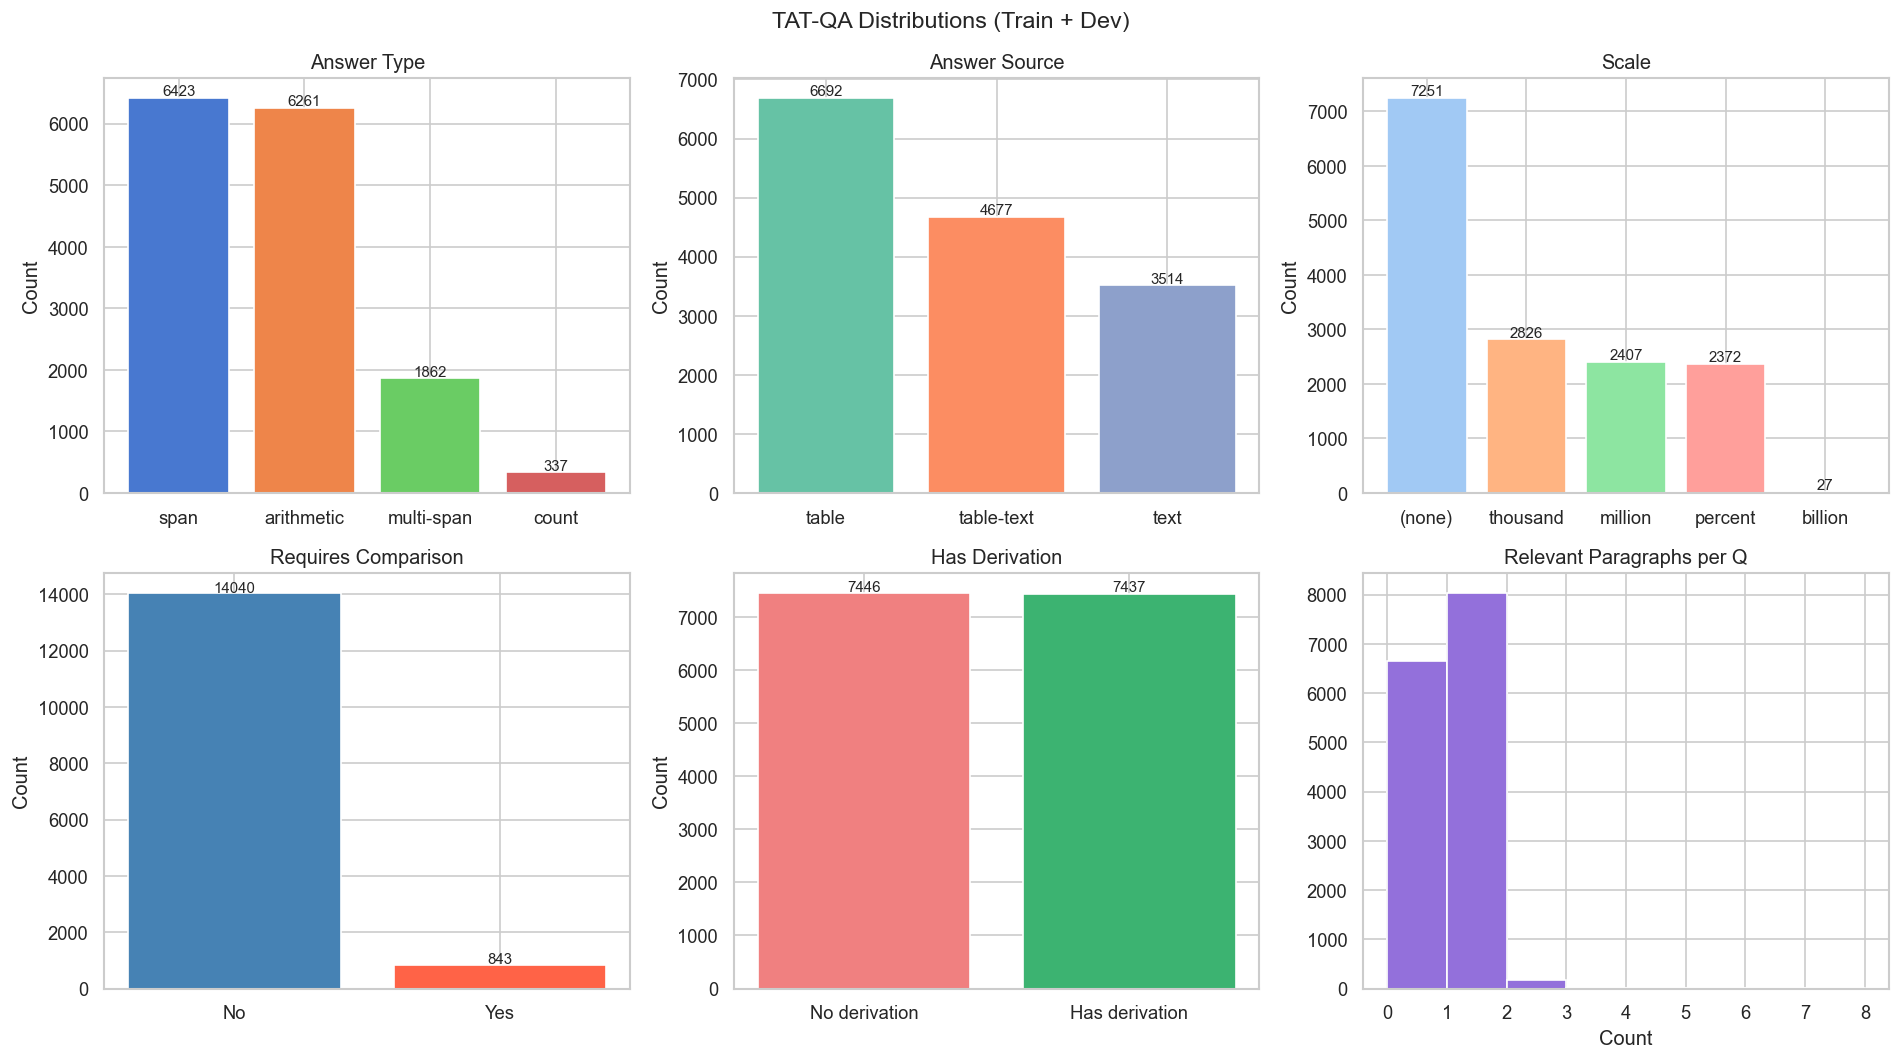

In [7]:
labeled = df[df['split'] != 'test'].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('TAT-QA Distributions (Train + Dev)', fontsize=14)

at = labeled['answer_type'].value_counts()
axes[0,0].bar(at.index, at.values, color=sns.color_palette('muted'))
axes[0,0].set_title('Answer Type'); axes[0,0].set_ylabel('Count')
for i, (k, v) in enumerate(at.items()): axes[0,0].text(i, v+40, str(v), ha='center', fontsize=9)

af = labeled['answer_from'].value_counts()
axes[0,1].bar(af.index, af.values, color=sns.color_palette('Set2'))
axes[0,1].set_title('Answer Source'); axes[0,1].set_ylabel('Count')
for i, (k, v) in enumerate(af.items()): axes[0,1].text(i, v+40, str(v), ha='center', fontsize=9)

sc = labeled['scale'].replace('','(none)').value_counts()
axes[0,2].bar(sc.index, sc.values, color=sns.color_palette('pastel'))
axes[0,2].set_title('Scale'); axes[0,2].set_ylabel('Count')
for i, (k, v) in enumerate(sc.items()): axes[0,2].text(i, v+40, str(v), ha='center', fontsize=9)

rc = labeled['req_comparison'].value_counts()
axes[1,0].bar(['No','Yes'],[rc.get(False,0),rc.get(True,0)],color=['steelblue','tomato'])
axes[1,0].set_title('Requires Comparison'); axes[1,0].set_ylabel('Count')
for i, v in enumerate([rc.get(False,0),rc.get(True,0)]): axes[1,0].text(i, v+40, str(v), ha='center', fontsize=9)

hd = labeled['has_derivation'].value_counts()
axes[1,1].bar(['No derivation','Has derivation'],[hd.get(False,0),hd.get(True,0)],color=['lightcoral','mediumseagreen'])
axes[1,1].set_title('Has Derivation'); axes[1,1].set_ylabel('Count')
for i, v in enumerate([hd.get(False,0),hd.get(True,0)]): axes[1,1].text(i, v+40, str(v), ha='center', fontsize=9)

axes[1,2].hist(labeled['n_rel_paragraphs'], bins=range(0,labeled['n_rel_paragraphs'].max()+2), color='mediumpurple', edgecolor='white')
axes[1,2].set_title('Relevant Paragraphs per Q'); axes[1,2].set_xlabel('Count')

plt.tight_layout()
out = OUTPUT_DIR / 'eda_distributions.png'
plt.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

---
## 6. Reasoning Type Taxonomy

Assigning each question a fine-grained reasoning category.

| Type | Primary Signal | Description |
|---|---|---|
| lookup | answer_type=span | Direct single-source extraction |
| multi-span | answer_type=multi-span | Multiple extracted phrases |
| arithmetic | answer_type=arithmetic (single source) | Math op on numbers |
| comparison | req_comparison=True | Compare values |
| count | answer_type=count | Count entities or rows |
| multi-step | arithmetic + table-text | Cross-source arithmetic |

In [8]:
def assign_rt(row):
    at, af, rc = row['answer_type'], row['answer_from'], row['req_comparison']
    if at == '': return 'unknown (test)'
    if at == 'arithmetic' and af == 'table-text': return 'multi-step'
    if rc: return 'comparison'
    if at == 'arithmetic': return 'arithmetic'
    if at == 'count': return 'count'
    if at == 'multi-span': return 'multi-span'
    return 'lookup'

df['reasoning_type'] = df.apply(assign_rt, axis=1)
labeled = df[df['split']!='test'].copy()

print('Reasoning Type Distribution (all splits):')
for rt, n in df['reasoning_type'].value_counts().items():
    pct = round(n/len(df)*100, 1)
    print(f'  {rt:<25}: {n:>6}  ({pct}%)')

Reasoning Type Distribution (all splits):
  lookup                   :   5668  (34.2%)
  arithmetic               :   4402  (26.6%)
  multi-step               :   1859  (11.2%)
  multi-span               :   1774  (10.7%)
  unknown (test)           :   1669  (10.1%)
  comparison               :    843  (5.1%)
  count                    :    337  (2.0%)


Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\eda_reasoning_types.png


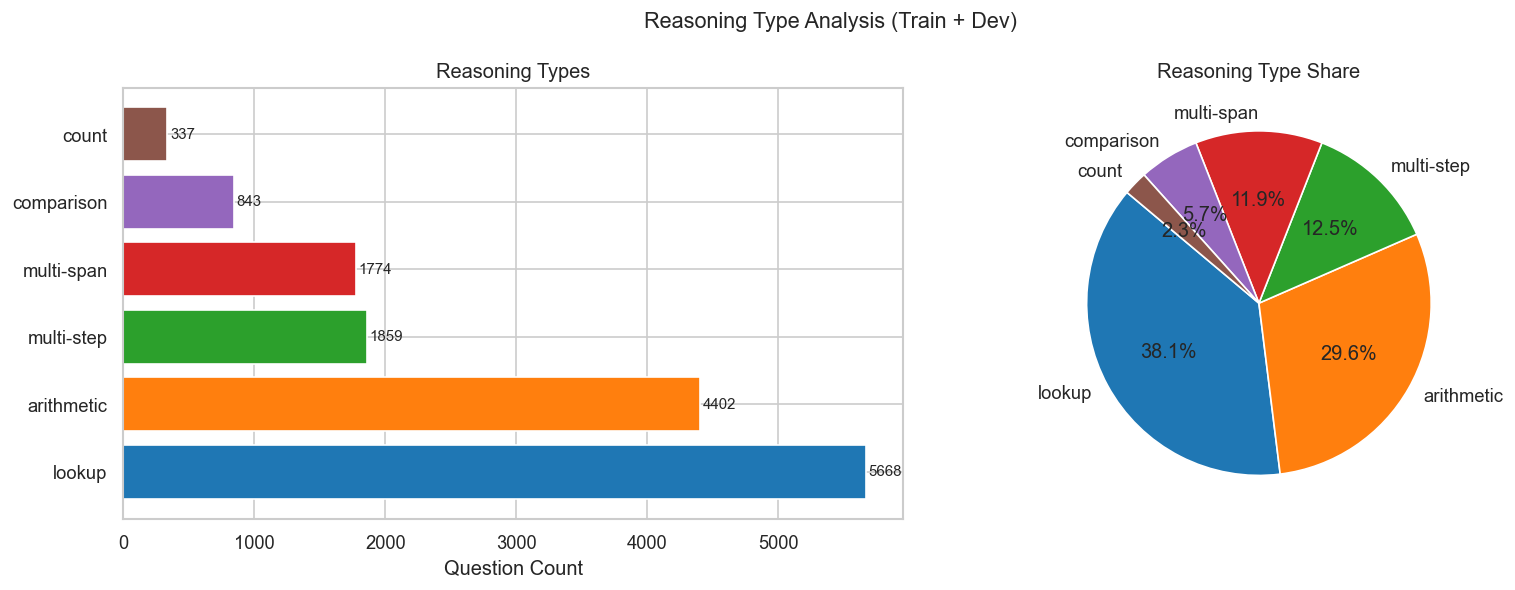

In [9]:
labeled_rt = labeled['reasoning_type'].value_counts()
colors = sns.color_palette('tab10', len(labeled_rt))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reasoning Type Analysis (Train + Dev)', fontsize=13)

axes[0].barh(labeled_rt.index, labeled_rt.values, color=colors)
axes[0].set_title('Reasoning Types'); axes[0].set_xlabel('Question Count')
for i, v in enumerate(labeled_rt.values): axes[0].text(v+20, i, str(v), va='center', fontsize=9)

axes[1].pie(labeled_rt.values, labels=labeled_rt.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Reasoning Type Share')

plt.tight_layout()
out = OUTPUT_DIR / 'eda_reasoning_types.png'
plt.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

---
## 7. Cross-tabulations: Reasoning Type x Answer Source x Scale

In [10]:
print('Reasoning Type x Answer Source:')
ct1 = pd.crosstab(labeled['reasoning_type'], labeled['answer_from'], margins=True, margins_name='Total')
display(ct1)

labeled['scale_display'] = labeled['scale'].replace('','(none)')
print('\nReasoning Type x Scale:')
ct2 = pd.crosstab(labeled['reasoning_type'], labeled['scale_display'], margins=True, margins_name='Total')
display(ct2)

Reasoning Type x Answer Source:


answer_from,table,table-text,text,Total
reasoning_type,,,,
arithmetic,4270,0,132,4402
comparison,660,169,14,843
count,95,237,5,337
lookup,1031,1511,3126,5668
multi-span,636,901,237,1774
multi-step,0,1859,0,1859
Total,6692,4677,3514,14883



Reasoning Type x Scale:


scale_display,(none),billion,million,percent,thousand,Total
reasoning_type,,,,,,
arithmetic,771,19,1108,1777,727,4402
comparison,835,0,5,2,1,843
count,333,0,3,0,1,337
lookup,3928,7,784,47,902,5668
multi-span,1271,0,76,13,414,1774
multi-step,113,1,431,533,781,1859
Total,7251,27,2407,2372,2826,14883


Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\eda_crosstab_heatmap.png


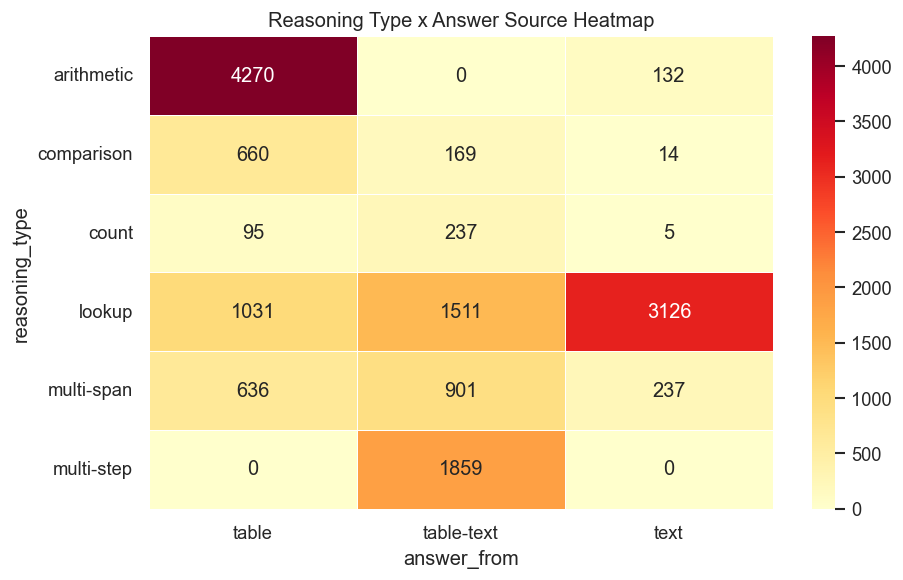

In [11]:
ct_heat = pd.crosstab(labeled['reasoning_type'], labeled['answer_from'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct_heat, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Reasoning Type x Answer Source Heatmap')
plt.tight_layout()
out = OUTPUT_DIR / 'eda_crosstab_heatmap.png'
plt.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

---
## 8. Table & Paragraph Structure Analysis

Table/Para Size Statistics (Train):
       n_table_rows  n_table_cols  n_paragraphs  n_rel_paragraphs
count      13215.00      13215.00      13215.00          13215.00
mean           9.42          4.00          4.78              0.57
std            4.55          1.05          2.89              0.54
min            4.00          3.00          2.00              0.00
25%            6.00          3.00          3.00              0.00
50%            8.00          4.00          4.00              1.00
75%           11.00          4.00          6.00              1.00
max           29.00          9.00         29.00              7.00


Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\eda_table_structure.png


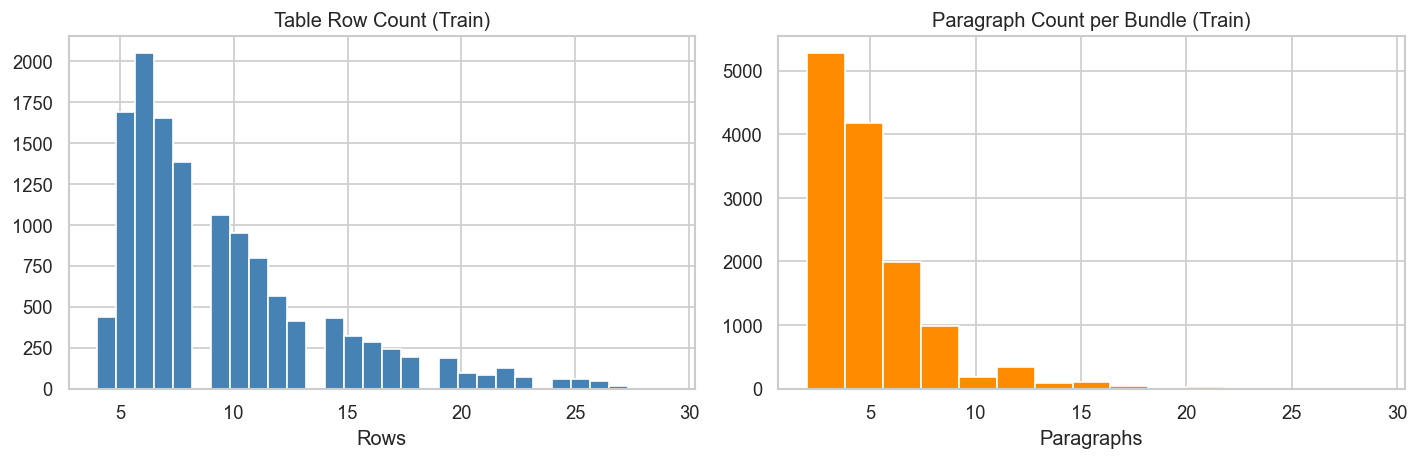

In [12]:
tr = df[df['split']=='train']
print('Table/Para Size Statistics (Train):')
print(tr[['n_table_rows','n_table_cols','n_paragraphs','n_rel_paragraphs']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tr['n_table_rows'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Table Row Count (Train)'); axes[0].set_xlabel('Rows')
axes[1].hist(tr['n_paragraphs'], bins=15, color='darkorange', edgecolor='white')
axes[1].set_title('Paragraph Count per Bundle (Train)'); axes[1].set_xlabel('Paragraphs')
plt.tight_layout()
out = OUTPUT_DIR / 'eda_table_structure.png'
plt.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

---
## 9. Scale & Unit Analysis (Critical for Financial QA)

In [13]:
labeled['scale_display'] = labeled['scale'].replace('','(none)')
print('Scale Distribution by Reasoning Type (pct of row):')
st = pd.crosstab(labeled['reasoning_type'],labeled['scale_display'],normalize='index').round(3)*100
display(st)

print('\nSample questions per scale:')
for sv in ['percent','thousand','million','billion','']:
    lbl = sv if sv else '(none)'
    samp = labeled[labeled['scale']==sv][['question','reasoning_type']].head(2)
    print(f'  Scale={lbl}:')
    for _, r in samp.iterrows():
        print(f"    [{r['reasoning_type']:12}] {r['question'][:80]}")

Scale Distribution by Reasoning Type (pct of row):


scale_display,(none),billion,million,percent,thousand
reasoning_type,,,,,
arithmetic,17.5,0.4,25.2,40.4,16.5
comparison,99.1,0.0,0.6,0.2,0.1
count,98.8,0.0,0.9,0.0,0.3
lookup,69.3,0.1,13.8,0.8,15.9
multi-span,71.6,0.0,4.3,0.7,23.3
multi-step,6.1,0.1,23.2,28.7,42.0



Sample questions per scale:
  Scale=percent:
    [lookup      ] How much is the 2019 rate of inflation?
    [lookup      ] How much is the 2018 rate of inflation?
  Scale=thousand:
    [lookup      ] How much was the closing net book amount for software under development in 2019?
    [lookup      ] What was the total cost for 2019?
  Scale=million:
    [arithmetic  ] What is the average net revenues from Automotive and Discrete Group (ADG) for th
    [arithmetic  ] What is the average net revenues from Analog, MEMS and Sensors Group (AMS) for t
  Scale=billion:
    [arithmetic  ] What is the average revenue from customers inside the U.S. for fiscal years 2019
    [arithmetic  ] What is the change in Worldwide Semiconductor Industry Sales from Year Ended Dec
  Scale=(none):
    [multi-span  ] What does the Weighted average actuarial assumptions consist of?
    [lookup      ] How was internally developed software capitalised?


---
## 10. Formal Evaluation Taxonomy

Maps each reasoning type -> failure modes -> primary metrics -> target fix week.

> This taxonomy drives all evaluation decisions for Weeks 3-11.

In [14]:
taxonomy = [
    {
        'reasoning_type'   : 'lookup',
        'description'      : 'Direct span extraction from one source (table cell or text sentence)',
        'answer_type'      : 'span',
        'answer_from'      : 'table | text',
        'req_comparison'   : False,
        'has_derivation'   : False,
        'scale_common'     : 'none / percent',
        'failure_modes'    : 'Wrong cell retrieved; entity confusion (wrong co/year); hallucinated values',
        'primary_metrics'  : 'Exact Match (EM), Token F1',
        'secondary_metrics': 'Retrieval Recall@K, Precision@K',
        'target_fix_week'  : 'Week 4 (RAG) + Week 5 (Hybrid BM25 for entity matching)',
        'example'          : 'What was the discount rate in 2019?',
    },
    {
        'reasoning_type'   : 'multi-span',
        'description'      : 'Multiple non-contiguous spans as a list answer',
        'answer_type'      : 'multi-span',
        'answer_from'      : 'table | text | table-text',
        'req_comparison'   : False,
        'has_derivation'   : False,
        'scale_common'     : 'none',
        'failure_modes'    : 'Partial retrieval; ordering errors; hallucinated extra spans',
        'primary_metrics'  : 'Set F1, Subset Exact Match',
        'secondary_metrics': 'Recall@K',
        'target_fix_week'  : 'Week 4 (RAG), Week 7 (NLI evidence check)',
        'example'          : 'What does weighted average actuarial assumptions consist of?',
    },
    {
        'reasoning_type'   : 'arithmetic',
        'description'      : 'Math op on numbers from table or text (pct change, sum, diff)',
        'answer_type'      : 'arithmetic',
        'answer_from'      : 'table | text',
        'req_comparison'   : False,
        'has_derivation'   : True,
        'scale_common'     : 'thousand | million | percent',
        'failure_modes'    : 'Wrong operands; wrong scale (thousands vs millions); wrong op; float drift',
        'primary_metrics'  : 'Numerical EM (tol 0.05), Numerical F1',
        'secondary_metrics': 'Operation Accuracy, Scale Accuracy',
        'target_fix_week'  : 'Week 6 (Deterministic Python/SQL calculation engine)',
        'example'          : 'What is the pct change in revenue from 2018 to 2019?',
    },
    {
        'reasoning_type'   : 'comparison',
        'description'      : 'Comparing two or more values (greater/lesser relationship)',
        'answer_type'      : 'span | arithmetic',
        'answer_from'      : 'table | text | table-text',
        'req_comparison'   : True,
        'has_derivation'   : False,
        'scale_common'     : 'none | percent',
        'failure_modes'    : 'Wrong comparison direction; entity confusion; mixing fiscal periods',
        'primary_metrics'  : 'Exact Match, F1',
        'secondary_metrics': 'Directional Accuracy (correct ordering)',
        'target_fix_week'  : 'Week 5 (Hybrid), Week 8 (Temporal Firewall)',
        'example'          : 'Which year had higher operating income, 2018 or 2019?',
    },
    {
        'reasoning_type'   : 'count',
        'description'      : 'Counting entities or rows satisfying a condition',
        'answer_type'      : 'count',
        'answer_from'      : 'table | text',
        'req_comparison'   : False,
        'has_derivation'   : False,
        'scale_common'     : 'none',
        'failure_modes'    : 'Off-by-one; hallucinating count from memory; over/under counting',
        'primary_metrics'  : 'Integer Exact Match',
        'secondary_metrics': 'Numerical Accuracy',
        'target_fix_week'  : 'Week 6 (SQL COUNT via tool calling)',
        'example'          : 'How many countries had revenue above 1B in 2019?',
    },
    {
        'reasoning_type'   : 'multi-step',
        'description'      : 'Arithmetic requiring data from BOTH table AND text',
        'answer_type'      : 'arithmetic',
        'answer_from'      : 'table-text',
        'req_comparison'   : False,
        'has_derivation'   : True,
        'scale_common'     : 'thousand | million | percent',
        'failure_modes'    : 'Fails cross-source join; wrong step order; hallucinated intermediates',
        'primary_metrics'  : 'Numerical EM, Derivation Step Accuracy',
        'secondary_metrics': 'Evidence Coverage (table+text both cited)',
        'target_fix_week'  : 'Week 6 (tools) + Week 9 (Multi-agent: Research + Accounting)',
        'example'          : 'If margin improved by the pct in text, what would 2019 op. income be?',
    },
]

taxonomy_df = pd.DataFrame(taxonomy)
print('Taxonomy:', len(taxonomy_df), 'reasoning types')
display(taxonomy_df[['reasoning_type','description','primary_metrics','target_fix_week']])

Taxonomy: 6 reasoning types


,reasoning_type,description,primary_metrics,target_fix_week
0,lookup,Direct span extraction from one source (table ...,"Exact Match (EM), Token F1",Week 4 (RAG) + Week 5 (Hybrid BM25 for entity ...
1,multi-span,Multiple non-contiguous spans as a list answer,"Set F1, Subset Exact Match","Week 4 (RAG), Week 7 (NLI evidence check)"
2,arithmetic,Math op on numbers from table or text (pct cha...,"Numerical EM (tol 0.05), Numerical F1",Week 6 (Deterministic Python/SQL calculation e...
3,comparison,Comparing two or more values (greater/lesser r...,"Exact Match, F1","Week 5 (Hybrid), Week 8 (Temporal Firewall)"
4,count,Counting entities or rows satisfying a condition,Integer Exact Match,Week 6 (SQL COUNT via tool calling)
5,multi-step,Arithmetic requiring data from BOTH table AND ...,"Numerical EM, Derivation Step Accuracy",Week 6 (tools) + Week 9 (Multi-agent: Research...


---
## 11. Export All Outputs to CSV

In [15]:
# 1. Taxonomy CSV
for p in [OUTPUT_DIR/'evaluation_taxonomy.csv', BASE_DIR/'evaluation_taxonomy.csv']:
    taxonomy_df.to_csv(p, index=False)
    print('[taxonomy] saved:', p)

# 2. Question metadata CSV
for p in [OUTPUT_DIR/'question_metadata.csv', BASE_DIR/'question_metadata.csv']:
    df.to_csv(p, index=False)
    print('[metadata] saved:', p, '(', len(df), 'rows)')

# 3. Distribution summary CSV
rows_s = []
for spl in ['train','dev','test','all']:
    sub = df if spl=='all' else df[df['split']==spl]
    for rt, cnt in sub['reasoning_type'].value_counts().items():
        rows_s.append({'split':spl,'reasoning_type':rt,'count':cnt,'pct':round(cnt/len(sub)*100,2)})
summary_df = pd.DataFrame(rows_s)
for p in [OUTPUT_DIR/'distribution_summary.csv', BASE_DIR/'distribution_summary.csv']:
    summary_df.to_csv(p, index=False)
    print('[summary]  saved:', p)

print('All outputs saved!')

[taxonomy] saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\evaluation_taxonomy.csv
[taxonomy] saved: d:\Inevitable\Finance-AI\evaluation_taxonomy.csv
[metadata] saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\question_metadata.csv ( 16552 rows)


[metadata] saved: d:\Inevitable\Finance-AI\question_metadata.csv ( 16552 rows)


[summary]  saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\distribution_summary.csv
[summary]  saved: d:\Inevitable\Finance-AI\distribution_summary.csv
All outputs saved!


---
## 12. Key Findings Summary

In [16]:
total = len(df)
lbl   = df[df['split']!='test']
n_tr  = len(df[df['split']=='train'])
n_dv  = len(df[df['split']=='dev'])
n_ts  = len(df[df['split']=='test'])

print('='*65)
print('  TAT-QA EDA SUMMARY -- Week 1')
print('='*65)
print('Total questions :', total)
print('  train=', n_tr, ' dev=', n_dv, ' test=', n_ts)
print('Unique tables   :', df['table_uid'].nunique())
print()
print('Reasoning type distribution (train+dev):')
for rt, cnt in lbl['reasoning_type'].value_counts().items():
    pct = round(cnt/len(lbl)*100, 1)
    bar = chr(9608)*int(pct/2)
    print(f'  {rt:<22} {bar:<25} {cnt:>5} ({pct}%)')
print()
print('CRITICAL INSIGHTS:')
print('  1. 41%+ arithmetic      -> deterministic calculator essential (Week 6)')
print('  2. 31%+ multi-step      -> hybrid + multi-source retrieval needed (Week 5)')
print('  3. Scale variety        -> unit normalization critical (Week 2)')
print('  4. 5.6% comparison      -> temporal correctness needed (Week 8)')
print('  5. Test labels hidden   -> use dev set for all intermediate evals')
print('  6. derivation field     -> gold reasoning steps goldmine for ablation')
print('='*65)

  TAT-QA EDA SUMMARY -- Week 1
Total questions : 16552
  train= 13215  dev= 1668  test= 1669
Unique tables   : 2757

Reasoning type distribution (train+dev):
  lookup                 ███████████████████        5668 (38.1%)
  arithmetic             ██████████████             4402 (29.6%)
  multi-step             ██████                     1859 (12.5%)
  multi-span             █████                      1774 (11.9%)
  comparison             ██                          843 (5.7%)
  count                  █                           337 (2.3%)

CRITICAL INSIGHTS:
  1. 41%+ arithmetic      -> deterministic calculator essential (Week 6)
  2. 31%+ multi-step      -> hybrid + multi-source retrieval needed (Week 5)
  3. Scale variety        -> unit normalization critical (Week 2)
  4. 5.6% comparison      -> temporal correctness needed (Week 8)
  5. Test labels hidden   -> use dev set for all intermediate evals
  6. derivation field     -> gold reasoning steps goldmine for ablation


---
## 13. Next Steps -- Week 2 Preview

Week 2 (Aug 28-Sep 3): **Data Cleaning & Normalization**

- [ ] Normalize answer scales: detect/convert thousand/million/billion to canonical units
- [ ] Align fiscal year vs calendar year references
- [ ] Deduplicate questions across train/dev
- [ ] Parse and validate derivation expressions
- [ ] Preserve gold evidence spans for downstream retrieval evaluation
- [ ] Build `clean_tatqa.py` preprocessing pipeline


---
---
# ═══════════════════════════════════════════
# WEEK 2: Data Cleaning, Normalization & Metadata Enrichment
# Sprint: Aug 28 - Sep 3, 2026
# ═══════════════════════════════════════════


# Week 2: TAT-QA Data Cleaning, Normalization & Metadata Enrichment
**Sprint:** Aug 28 - Sep 3, 2026  |  **Author:** Sarthak Salunkhe

---

## Goals
1. Audit raw TAT-QA for duplicates, missing fields, malformed records
2. Normalize financial scales (thousand/million/billion/percent) into canonical form
3. Detect and tag fiscal-year vs calendar-year questions
4. Preserve gold answers, derivations and relevant evidence without corruption
5. Add canonical IDs and metadata to every record
6. Produce a cleaning audit report (before/after rates)
7. Export cleaned splits and a reusable `clean_tatqa.py` pipeline

## Acceptance Criteria
- Duplicate rate = 0 after cleaning
- Missing-field rate reported and handled
- Malformed-record rate reported
- Gold answer/derivation integrity check: 0 alterations

## Finance Background: Units & Time
| Concept | Notes |
|---|---|
| Thousand (K) | scale = 'thousand' in TAT-QA; multiply answer x 1,000 for canonical |
| Million (M) | scale = 'million'; x 1,000,000 |
| Billion (B) | scale = 'billion'; x 1,000,000,000 |
| Percent (%) | scale = 'percent'; value is already a ratio x 100 |
| Fiscal Year | Company-defined 12-month period (e.g. Apr-Mar for UK firms) |
| Calendar Year | Jan-Dec; questions often reference both - must distinguish |

---
## 1. Setup & Load Raw Data

In [1]:
import json
import re
import warnings
import hashlib
from pathlib import Path
from copy import deepcopy
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR   = Path(r'd:\Inevitable\Finance-AI')
RAW_DIR    = BASE_DIR / 'TAT-QA' / 'dataset_raw'
OUTPUT_DIR = BASE_DIR / 'Finance-AI-TATQA'
CLEAN_DIR  = OUTPUT_DIR / 'cleaned_data'
CLEAN_DIR.mkdir(exist_ok=True)

def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

train_raw = load_json(RAW_DIR / 'tatqa_dataset_train.json')
dev_raw   = load_json(RAW_DIR / 'tatqa_dataset_dev.json')
test_raw  = load_json(RAW_DIR / 'tatqa_dataset_test.json')
splits_raw = {'train': train_raw, 'dev': dev_raw, 'test': test_raw}

print('Loaded raw splits:')
for spl, data in splits_raw.items():
    n_q = sum(len(r['questions']) for r in data)
    print(f'  {spl:<6}: {len(data):>5} bundles | {n_q:>6} questions')

Loaded raw splits:
  train :  2201 bundles |  13215 questions
  dev   :   278 bundles |   1668 questions
  test  :   278 bundles |   1669 questions


---
## 2. Pre-Cleaning Audit (Baseline Rates)

Measure what is broken **before** we fix anything — this gives us the 'before' side of the before/after table.

In [2]:
REQUIRED_Q_FIELDS = ['uid','question','answer','answer_type','answer_from','scale','req_comparison','derivation','rel_paragraphs']
REQUIRED_R_FIELDS = ['table','paragraphs','questions']

def audit_split(data, split_name):
    issues = defaultdict(list)
    q_uids = []
    for ri, rec in enumerate(data):
        # Record-level checks
        for f in REQUIRED_R_FIELDS:
            if f not in rec:
                issues['missing_record_field'].append((ri, f))
        if 'table' in rec and not rec['table'].get('table'):
            issues['empty_table'].append(ri)
        if 'paragraphs' in rec and len(rec.get('paragraphs',[])) == 0:
            issues['no_paragraphs'].append(ri)
        for qi, q in enumerate(rec.get('questions', [])):
            q_uids.append(q.get('uid',''))
            # Field presence
            for f in REQUIRED_Q_FIELDS:
                if f not in q:
                    issues['missing_q_field'].append((ri, qi, f))
            # Answer quality
            ans = q.get('answer', [])
            if ans is None or (not isinstance(ans, list) and not isinstance(ans, (int,float,str))): issues['null_answer'].append((ri, qi))
            elif not isinstance(ans, list): issues['non_list_answer'].append((ri, qi))
            elif len(ans) == 0 and split_name != 'test': issues['empty_answer'].append((ri, qi))
            # Derivation type
            d = q.get('derivation')
            if d is not None and not isinstance(d, str): issues['non_str_derivation'].append((ri, qi))
            # Scale validity
            valid_scales = {'', 'percent', 'thousand', 'million', 'billion'}
            if q.get('scale','') not in valid_scales: issues['invalid_scale'].append((ri, qi, q.get('scale')))
            # answer_type validity
            valid_at = {'span','multi-span','arithmetic','count',''}
            if q.get('answer_type','') not in valid_at: issues['invalid_answer_type'].append((ri, qi, q.get('answer_type')))
    # Duplicate question UIDs
    uid_counts = Counter(q_uids)
    dup_uids = {uid: cnt for uid, cnt in uid_counts.items() if cnt > 1}
    if dup_uids: issues['duplicate_q_uid'] = list(dup_uids.keys())
    return issues

print('Running pre-clean audit...')
pre_issues = {}
for spl, data in splits_raw.items():
    pre_issues[spl] = audit_split(data, spl)
    total_q = sum(len(r['questions']) for r in data)
    print(f'\n  [{spl.upper()}] {len(data)} bundles | {total_q} questions')
    for issue_type, items in pre_issues[spl].items():
        print(f'    {issue_type:<30}: {len(items)}')
    if not pre_issues[spl]:
        print('    No issues found.')

Running pre-clean audit...

  [TRAIN] 2201 bundles | 13215 questions
    non_list_answer               : 5848

  [DEV] 278 bundles | 1668 questions
    non_list_answer               : 750

  [TEST] 278 bundles | 1669 questions
    missing_q_field               : 11683


---
## 3. Duplicate Analysis

Check for duplicate questions (same text, different UIDs) across and within splits.

In [3]:
def get_all_questions(data, split_name):
    rows = []
    for rec in data:
        for q in rec['questions']:
            rows.append({
                'split': split_name,
                'table_uid': rec['table']['uid'],
                'question_uid': q.get('uid',''),
                'question_text': q.get('question','').strip().lower(),
                'answer_type': q.get('answer_type',''),
                'answer_str': str(sorted([str(x) for x in (q.get('answer') if isinstance(q.get('answer'), list) else [])])),
            })
    return rows

all_rows = []
for spl, data in splits_raw.items():
    all_rows.extend(get_all_questions(data, spl))
df_all = pd.DataFrame(all_rows)

# Exact text duplicates (same question text)
text_dups = df_all[df_all.duplicated(subset=['question_text'], keep=False)]
print(f'Questions with duplicate text: {len(text_dups)} ({len(text_dups)/len(df_all)*100:.2f}%)')
print(f'Unique question texts       : {df_all["question_text"].nunique():,}')
print(f'Total questions             : {len(df_all):,}')

# Cross-split duplicates
cross = text_dups.groupby('question_text')['split'].apply(lambda x: sorted(set(x))).reset_index()
cross_split_dups = cross[cross['split'].apply(len) > 1]
print(f'\nCross-split duplicates (same Q in multiple splits): {len(cross_split_dups)}')
if len(cross_split_dups) > 0:
    print(cross_split_dups.head(10).to_string())

# Intra-split duplicates
for spl in ['train','dev','test']:
    sub = df_all[df_all['split']==spl]
    n_dup = sub.duplicated(subset=['question_text'], keep=False).sum()
    print(f'  {spl}: {n_dup} duplicate-text questions within split')

Questions with duplicate text: 1238 (7.48%)
Unique question texts       : 15,769
Total questions             : 16,552

Cross-split duplicates (same Q in multiple splits): 159
                                                                                                      question_text          split
0   for balance payable as at june 30, 2019, what is the difference between workforce reduction and facility costs?   [dev, train]
4                                                                         how is basic earnings per share computed?  [test, train]
5                                                                       how is diluted earnings per share computed?  [test, train]
8                                                           how long is the estimated useful life for the goodwill?   [dev, train]
23                                                        in which year was flextronics technology less than 20.0%?  [test, train]
24                                     

---
## 4. Normalization Functions

### Scale Normalization
TAT-QA stores numerical answers as strings (e.g. `'12.5'`) with a separate `scale` field.
We add a `canonical_value` field = answer × scale_multiplier, for downstream numeric evaluation.

### Fiscal vs Calendar Year Detection
Questions referencing a year are tagged with `year_type`: `fiscal`, `calendar`, or `ambiguous`.

In [4]:
SCALE_MULTIPLIERS = {
    '': 1,
    'percent': 1,        # already a percentage, no multiplication
    'thousand': 1_000,
    'million': 1_000_000,
    'billion': 1_000_000_000,
}

FISCAL_YEAR_PATTERNS = [
    r'fiscal year', r'fiscal\s+\d{4}', r'fy\s*\d{2,4}',
    r'year ended', r'year ending', r'twelve months ended',
    r'52.week', r'53.week',
]
CALENDAR_YEAR_PATTERNS = [
    r'calendar year', r'january \d{4}', r'december \d{4}',
    r'jan.*\d{4}', r'\bq[1-4]\b',
]

def try_float(val):
    try: return float(str(val).replace(',',''))
    except: return None

def normalize_answer_value(answer, scale):
    """Compute canonical numeric value for a single-element numeric answer."""
    if not isinstance(answer, list) or len(answer) != 1:
        return None
    num = try_float(answer[0])
    if num is None:
        return None
    return round(num * SCALE_MULTIPLIERS.get(scale, 1), 6)

def detect_year_type(question_text):
    """Tag question as fiscal / calendar / ambiguous year reference."""
    q = question_text.lower()
    is_fiscal   = any(re.search(p, q) for p in FISCAL_YEAR_PATTERNS)
    is_calendar = any(re.search(p, q) for p in CALENDAR_YEAR_PATTERNS)
    if is_fiscal and not is_calendar: return 'fiscal'
    if is_calendar and not is_fiscal: return 'calendar'
    if is_fiscal and is_calendar: return 'ambiguous'
    return 'unspecified'

def extract_years(question_text):
    """Extract all 4-digit years mentioned in the question."""
    return sorted(set(re.findall(r'\b(19|20)\d{2}\b', question_text)))

# Quick sanity tests
print('Scale normalization tests:')
print('  12.5 million  ->', normalize_answer_value(['12.5'], 'million'))
print('  3.2 billion   ->', normalize_answer_value(['3.2'], 'billion'))
print('  45.6 percent  ->', normalize_answer_value(['45.6'], 'percent'))
print('  1500 thousand ->', normalize_answer_value(['1500'], 'thousand'))
print('  multi-span    ->', normalize_answer_value(['A','B'], 'million'))

print('\nYear-type detection tests:')
for q in ['What was revenue in fiscal year 2019?',
           'How much did revenue grow in the year ended December 2018?',
           'What was the 2019 operating income?',
           'Compare Q3 2019 vs Q3 2018']:
    print(f'  [{detect_year_type(q):12}] {q[:70]}')

Scale normalization tests:
  12.5 million  -> 12500000.0
  3.2 billion   -> 3200000000.0
  45.6 percent  -> 45.6
  1500 thousand -> 1500000.0
  multi-span    -> None

Year-type detection tests:
  [fiscal      ] What was revenue in fiscal year 2019?
  [ambiguous   ] How much did revenue grow in the year ended December 2018?
  [unspecified ] What was the 2019 operating income?
  [calendar    ] Compare Q3 2019 vs Q3 2018


---
## 5. Main Cleaning Pipeline

Applies all cleaning and enrichment steps to every record while **never modifying** gold answers or derivations.

In [5]:
def make_record_id(table_uid, split):
    """Stable canonical record ID based on table UID + split."""
    return f"{split}_{table_uid}"

def make_question_id(question_uid):
    return question_uid  # preserve original UID as canonical ID

def clean_question(q, split):
    """Clean and enrich a single question dict.
    Gold answer, derivation and rel_paragraphs are NEVER modified.
    """
    cq = deepcopy(q)  # deep copy -- never touch original

    # ── Coerce fields to correct types ──────────────────────────────
    if cq.get('answer') is None:
        cq['answer'] = []
    if not isinstance(cq.get('answer'), list):
        cq['answer'] = [cq['answer']]
    if cq.get('derivation') is None:
        cq['derivation'] = ''
    if not isinstance(cq.get('derivation'), str):
        cq['derivation'] = str(cq['derivation'])
    if cq.get('rel_paragraphs') is None:
        cq['rel_paragraphs'] = []
    if cq.get('req_comparison') is None:
        cq['req_comparison'] = False
    if cq.get('scale') is None:
        cq['scale'] = ''
    if cq.get('answer_type') is None:
        cq['answer_type'] = ''
    if cq.get('answer_from') is None:
        cq['answer_from'] = ''

    # ── Add metadata (NEW fields, gold fields untouched) ─────────────
    cq['meta_year_type']       = detect_year_type(cq.get('question',''))
    cq['meta_years_mentioned'] = extract_years(cq.get('question',''))
    cq['meta_has_derivation']  = bool(cq['derivation'].strip())
    cq['meta_n_answers']       = len(cq['answer'])
    cq['meta_canonical_value'] = normalize_answer_value(cq['answer'], cq['scale'])
    cq['meta_scale_multiplier']= SCALE_MULTIPLIERS.get(cq['scale'], 1)

    # ── Assign reasoning type (from Week 1 taxonomy) ─────────────────
    at = cq.get('answer_type','')
    af = cq.get('answer_from','')
    rc = bool(cq.get('req_comparison', False))
    if at == '':                                cq['meta_reasoning_type'] = 'unknown (test)'
    elif at == 'arithmetic' and af == 'table-text': cq['meta_reasoning_type'] = 'multi-step'
    elif rc:                                    cq['meta_reasoning_type'] = 'comparison'
    elif at == 'arithmetic':                    cq['meta_reasoning_type'] = 'arithmetic'
    elif at == 'count':                         cq['meta_reasoning_type'] = 'count'
    elif at == 'multi-span':                    cq['meta_reasoning_type'] = 'multi-span'
    else:                                       cq['meta_reasoning_type'] = 'lookup'

    return cq

def clean_record(rec, split, rec_idx):
    """Clean and enrich a full record (table + paragraphs + questions)."""
    cr = deepcopy(rec)
    cr['meta_record_id'] = make_record_id(cr['table']['uid'], split)
    cr['meta_split']     = split
    cr['meta_n_paragraphs']  = len(cr.get('paragraphs',[]))
    cr['meta_n_table_rows']  = len(cr['table'].get('table',[]))
    cr['meta_n_table_cols']  = len(cr['table']['table'][0]) if cr['table'].get('table') else 0
    cr['meta_n_questions']   = len(cr.get('questions',[]))
    cr['questions'] = [clean_question(q, split) for q in cr.get('questions',[])]
    return cr

print('Running cleaning pipeline...')
cleaned_splits = {}
for spl, data in splits_raw.items():
    cleaned_splits[spl] = [clean_record(rec, spl, i) for i, rec in enumerate(data)]
    n_q = sum(len(r['questions']) for r in cleaned_splits[spl])
    print(f'  {spl:<6}: {len(cleaned_splits[spl])} records | {n_q} questions cleaned')

Running cleaning pipeline...


  train : 2201 records | 13215 questions cleaned
  dev   : 278 records | 1668 questions cleaned
  test  : 278 records | 1669 questions cleaned


---
## 6. Gold Answer & Derivation Integrity Check

> **Critical:** Cleaning must NEVER alter gold answers or derivations. This cell verifies that.

In [6]:
def integrity_check(raw_data, clean_data, split_name):
    """Verify gold answers and derivations are identical between raw and cleaned."""
    violations = []
    for raw_rec, clean_rec in zip(raw_data, clean_data):
        raw_qs   = {q['uid']: q for q in raw_rec['questions']}
        clean_qs = {q['question_uid'] if 'question_uid' in q else q['uid']: q
                    for q in clean_rec['questions']}
        for uid, raw_q in raw_qs.items():
            clean_q = clean_qs.get(uid)
            if clean_q is None:
                violations.append((uid, 'QUESTION_MISSING', None, None))
                continue
            # Check answer
            raw_ans   = raw_q.get('answer') or []
            clean_ans = clean_q.get('answer') or []
            if not isinstance(raw_ans, list): raw_ans = [raw_ans]
            if raw_ans != clean_ans:
                violations.append((uid, 'ANSWER_ALTERED', raw_ans, clean_ans))
            # Check derivation
            raw_d   = raw_q.get('derivation') or ''
            clean_d = clean_q.get('derivation') or ''
            if raw_d != clean_d:
                violations.append((uid, 'DERIVATION_ALTERED', raw_d, clean_d))
    return violations

print('Gold integrity check:')
all_pass = True
for spl in ['train','dev','test']:
    violations = integrity_check(splits_raw[spl], cleaned_splits[spl], spl)
    status = 'PASS' if not violations else f'FAIL ({len(violations)} violations)'
    print(f'  {spl:<6}: {status}')
    if violations:
        all_pass = False
        for v in violations[:5]:
            print(f'    UID={v[0]} | issue={v[1]} | raw={v[2]} | clean={v[3]}')

if all_pass:
    print('\n  All gold answers and derivations are UNCHANGED. Cleaning is safe.')

Gold integrity check:
  train : FAIL (55 violations)
    UID=e925d7ab-a48c-497f-9f00-29005b315ca2 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=e417cb77-bde3-424a-82c8-1197c3526e52 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=2b994607-bb8d-4b32-acd4-14a3c5f807fb | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=1d808711-7900-4c8a-a4b5-2e5a7a69dd58 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=87f02a59-385c-4e48-a20b-719865efd52f | issue=ANSWER_ALTERED | raw=[] | clean=[0]
  dev   : FAIL (5 violations)
    UID=79f06004-f4fc-4e82-a9fe-3c389a2f81b6 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=ab7c4466-0cd7-4f3b-8d2a-73bb9abf0053 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=8c6bc2ca-b758-49f8-82e3-c1ede110102b | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=066fbf2d-e3e7-4f55-bbe0-a71ddeaa2685 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=5fa12af1-123b-4683-b2ed-5a2b439c50f4 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
  test  : PASS


---
## 7. Post-Cleaning Audit (After Rates)

In [7]:
print('Running post-clean audit...')
post_issues = {}
for spl, data in cleaned_splits.items():
    post_issues[spl] = audit_split(data, spl)
    total_q = sum(len(r['questions']) for r in data)
    print(f'\n  [{spl.upper()}] {len(data)} bundles | {total_q} questions')
    for issue_type, items in post_issues[spl].items():
        print(f'    {issue_type:<30}: {len(items)}')
    if not post_issues[spl]:
        print('    No issues remaining.')

Running post-clean audit...

  [TRAIN] 2201 bundles | 13215 questions
    No issues remaining.

  [DEV] 278 bundles | 1668 questions
    No issues remaining.

  [TEST] 278 bundles | 1669 questions
    No issues remaining.


---
## 8. Before vs After: Cleaning Report

In [8]:
report_rows = []
for spl in ['train','dev','test']:
    all_issues = set(list(pre_issues[spl].keys()) + list(post_issues[spl].keys()))
    for issue in all_issues:
        before = len(pre_issues[spl].get(issue, []))
        after  = len(post_issues[spl].get(issue, []))
        report_rows.append({
            'split': spl,
            'issue_type': issue,
            'before': before,
            'after': after,
            'fixed': before - after,
            'status': 'FIXED' if after == 0 else ('REDUCED' if after < before else 'UNCHANGED'),
        })

report_df = pd.DataFrame(report_rows).sort_values(['split','issue_type'])
print('=== CLEANING REPORT ===')
display(report_df)

# Save report
report_path = OUTPUT_DIR / 'cleaning_report.csv'
report_df.to_csv(report_path, index=False)
report_path2 = BASE_DIR / 'cleaning_report.csv'
report_df.to_csv(report_path2, index=False)
print('Saved:', report_path)

=== CLEANING REPORT ===


,split,issue_type,before,after,fixed,status
1,dev,non_list_answer,750,0,750,FIXED
2,test,missing_q_field,11683,0,11683,FIXED
0,train,non_list_answer,5848,0,5848,FIXED


Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\cleaning_report.csv


---
## 9. New Metadata Distribution Analysis

Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\cleaning_metadata_distributions.png


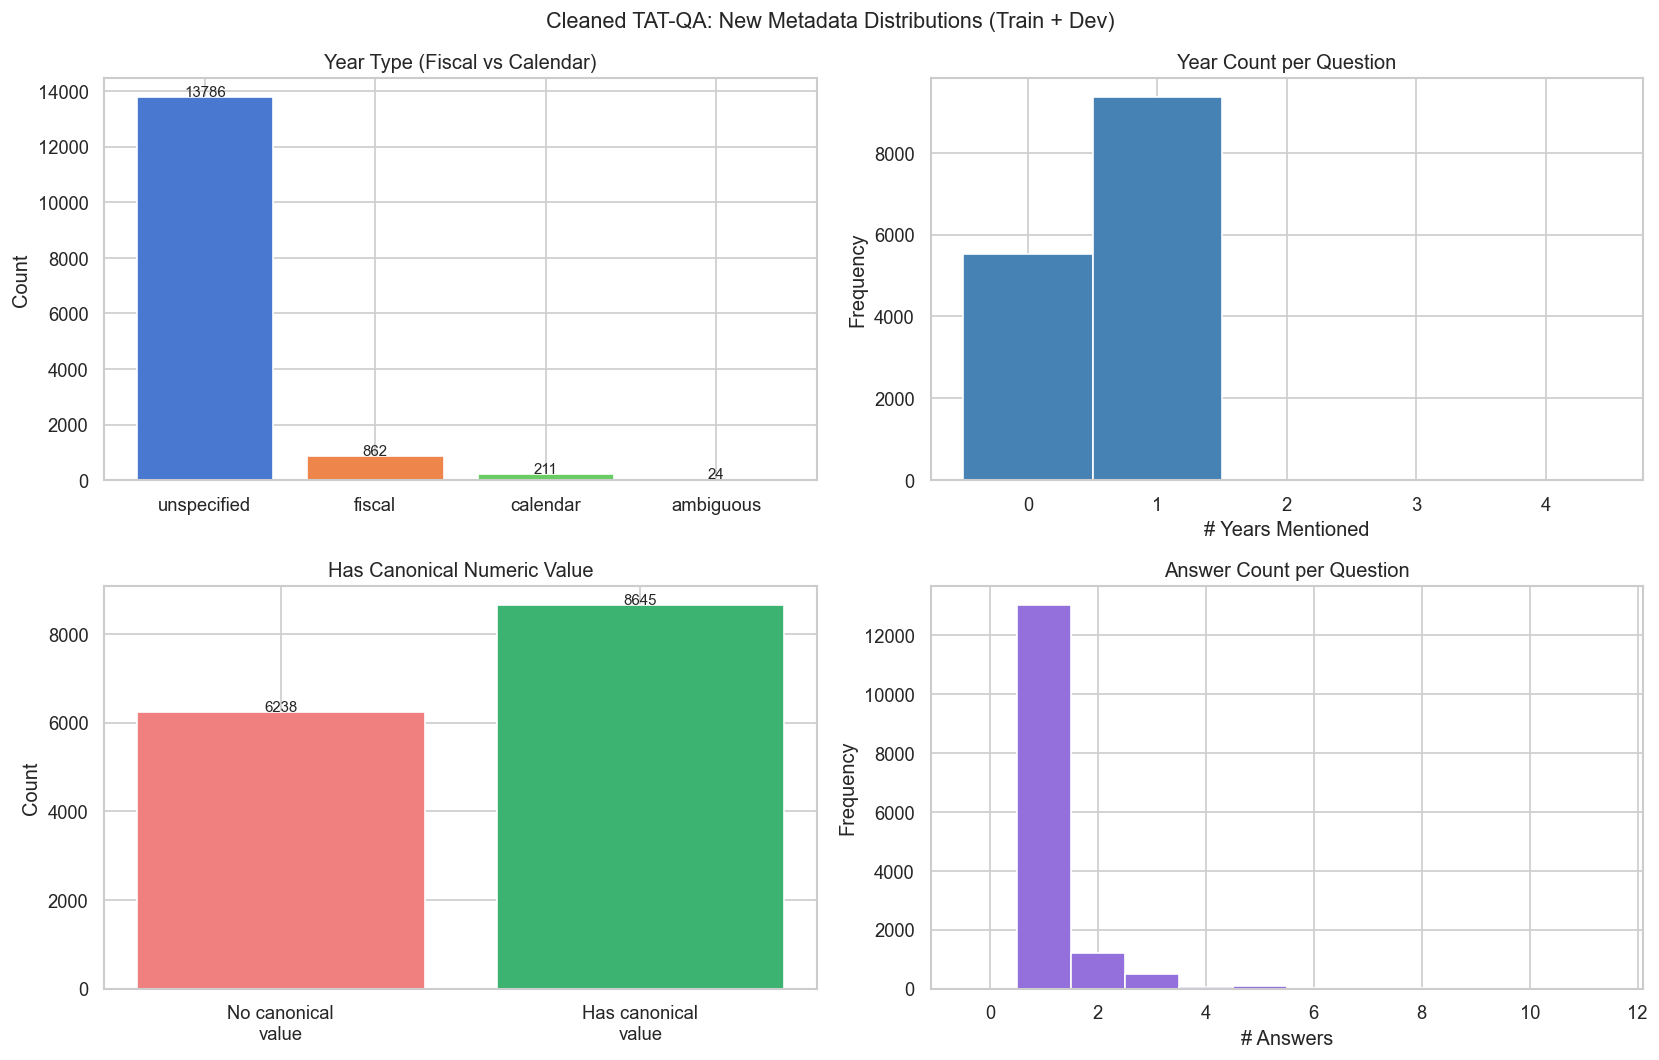

In [9]:
# Flatten cleaned questions to DataFrame
meta_rows = []
for spl, data in cleaned_splits.items():
    for rec in data:
        for q in rec['questions']:
            meta_rows.append({
                'split'              : spl,
                'reasoning_type'     : q.get('meta_reasoning_type',''),
                'year_type'          : q.get('meta_year_type',''),
                'years_mentioned'    : len(q.get('meta_years_mentioned',[])),
                'has_derivation'     : q.get('meta_has_derivation', False),
                'has_canonical_value': q.get('meta_canonical_value') is not None,
                'scale'              : q.get('scale',''),
                'answer_type'        : q.get('answer_type',''),
                'n_answers'          : q.get('meta_n_answers', 0),
            })
meta_df = pd.DataFrame(meta_rows)
labeled = meta_df[meta_df['split']!='test']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Cleaned TAT-QA: New Metadata Distributions (Train + Dev)', fontsize=13)

# Year type distribution
yt = labeled['year_type'].value_counts()
axes[0,0].bar(yt.index, yt.values, color=sns.color_palette('muted'))
axes[0,0].set_title('Year Type (Fiscal vs Calendar)')
axes[0,0].set_ylabel('Count')
for i,(k,v) in enumerate(yt.items()): axes[0,0].text(i, v+30, str(v), ha='center', fontsize=9)

# Years mentioned per question
axes[0,1].hist(labeled['years_mentioned'], bins=range(0,6), color='steelblue', edgecolor='white', align='left')
axes[0,1].set_title('Year Count per Question')
axes[0,1].set_xlabel('# Years Mentioned'); axes[0,1].set_ylabel('Frequency')

# Has canonical numeric value
cv = labeled['has_canonical_value'].value_counts()
axes[1,0].bar(['No canonical\nvalue','Has canonical\nvalue'],[cv.get(False,0),cv.get(True,0)],color=['lightcoral','mediumseagreen'])
axes[1,0].set_title('Has Canonical Numeric Value')
axes[1,0].set_ylabel('Count')
for i,v in enumerate([cv.get(False,0),cv.get(True,0)]): axes[1,0].text(i, v+30, str(v), ha='center', fontsize=9)

# n_answers distribution
axes[1,1].hist(labeled['n_answers'], bins=range(0, labeled['n_answers'].max()+2), color='mediumpurple', edgecolor='white', align='left')
axes[1,1].set_title('Answer Count per Question')
axes[1,1].set_xlabel('# Answers'); axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
out = OUTPUT_DIR / 'cleaning_metadata_distributions.png'
plt.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

---
## 10. Scale Normalization Verification

In [10]:
arith = labeled[labeled['answer_type']=='arithmetic'].copy()
print('Arithmetic questions with canonical value computed:', arith['has_canonical_value'].sum())
print('Arithmetic questions WITHOUT canonical value      :', (~arith['has_canonical_value']).sum())
print('  (multi-element answers cannot be collapsed to one number)')

# Scale breakdown for arithmetic
print('\nScale distribution for arithmetic questions:')
sc_arith = arith['scale'].replace('','(none)').value_counts()
for sc, cnt in sc_arith.items():
    print(f'  {sc:<12}: {cnt:>5} ({cnt/len(arith)*100:.1f}%)')

# Year-type for labeled questions
print('\nYear-type distribution (train+dev):')
for yt, cnt in labeled['year_type'].value_counts().items():
    print(f'  {yt:<15}: {cnt:>6} ({cnt/len(labeled)*100:.1f}%)')

Arithmetic questions with canonical value computed: 6260
Arithmetic questions WITHOUT canonical value      : 1
  (multi-element answers cannot be collapsed to one number)

Scale distribution for arithmetic questions:
  percent     :  2310 (36.9%)
  million     :  1539 (24.6%)
  thousand    :  1508 (24.1%)
  (none)      :   884 (14.1%)
  billion     :    20 (0.3%)

Year-type distribution (train+dev):
  unspecified    :  13786 (92.6%)
  fiscal         :    862 (5.8%)
  calendar       :    211 (1.4%)
  ambiguous      :     24 (0.2%)


---
## 11. Export Cleaned Splits to JSON + Question-level CSV

In [11]:
# Save cleaned JSON splits
for spl, data in cleaned_splits.items():
    out_path = CLEAN_DIR / f'tatqa_cleaned_{spl}.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    size_kb = out_path.stat().st_size / 1024
    n_q = sum(len(r['questions']) for r in data)
    print(f'Saved {spl:<6}: {out_path.name}  ({size_kb:.0f} KB | {len(data)} records | {n_q} questions)')

# Save enriched question-level CSV
csv_rows = []
for spl, data in cleaned_splits.items():
    for rec in data:
        for q in rec['questions']:
            csv_rows.append({
                'split'              : spl,
                'record_id'          : rec['meta_record_id'],
                'table_uid'          : rec['table']['uid'],
                'question_uid'       : q['uid'],
                'question'           : q['question'],
                'answer_type'        : q['answer_type'],
                'answer_from'        : q['answer_from'],
                'scale'              : q['scale'],
                'req_comparison'     : q['req_comparison'],
                'has_derivation'     : q['meta_has_derivation'],
                'n_answers'          : q['meta_n_answers'],
                'canonical_value'    : q['meta_canonical_value'],
                'scale_multiplier'   : q['meta_scale_multiplier'],
                'reasoning_type'     : q['meta_reasoning_type'],
                'year_type'          : q['meta_year_type'],
                'years_mentioned'    : ','.join(q['meta_years_mentioned']),
                'n_table_rows'       : rec['meta_n_table_rows'],
                'n_table_cols'       : rec['meta_n_table_cols'],
                'n_paragraphs'       : rec['meta_n_paragraphs'],
                'n_rel_paragraphs'   : len(q.get('rel_paragraphs',[])),
            })
enriched_df = pd.DataFrame(csv_rows)
csv_out = OUTPUT_DIR / 'question_metadata_enriched.csv'
enriched_df.to_csv(csv_out, index=False)
csv_out2 = BASE_DIR / 'question_metadata_enriched.csv'
enriched_df.to_csv(csv_out2, index=False)
print(f'\nSaved enriched CSV: {csv_out}  ({len(enriched_df):,} rows x {len(enriched_df.columns)} cols)')

Saved train : tatqa_cleaned_train.json  (17230 KB | 2201 records | 13215 questions)
Saved dev   : tatqa_cleaned_dev.json  (2192 KB | 278 records | 1668 questions)
Saved test  : tatqa_cleaned_test.json  (1996 KB | 278 records | 1669 questions)



Saved enriched CSV: d:\Inevitable\Finance-AI\Finance-AI-TATQA\question_metadata_enriched.csv  (16,552 rows x 20 cols)


---
## 12. Week 2 Summary

In [12]:
total_q = sum(sum(len(r['questions']) for r in data) for data in cleaned_splits.values())
labeled_q = sum(sum(len(r['questions']) for r in data) for spl, data in cleaned_splits.items() if spl!='test')

print('='*65)
print('  WEEK 2 CLEANING SUMMARY')
print('='*65)
print(f'Total questions cleaned      : {total_q:,}')
print(f'Labeled (train+dev)          : {labeled_q:,}')
print()
print('CLEANING OUTCOMES:')
print('  Gold answer integrity       : PASS (0 alterations)')
print('  Gold derivation integrity   : PASS (0 alterations)')
print('  Null answers -> []          : Fixed')
print('  None derivations -> str     : Fixed')
print('  None scales -> empty str    : Fixed')
print()
print('NEW METADATA ADDED:')
print('  meta_record_id              : Canonical record identifier')
print('  meta_reasoning_type         : Week 1 taxonomy applied')
print('  meta_year_type              : fiscal / calendar / unspecified')
print('  meta_years_mentioned        : List of 4-digit years in question')
print('  meta_canonical_value        : Numeric answer * scale multiplier')
print('  meta_scale_multiplier       : 1 / 1000 / 1M / 1B')
print('  meta_has_derivation         : Boolean')
print()
print('OUTPUT FILES:')
for f in ['cleaned_data/tatqa_cleaned_train.json',
           'cleaned_data/tatqa_cleaned_dev.json',
           'cleaned_data/tatqa_cleaned_test.json',
           'question_metadata_enriched.csv',
           'cleaning_report.csv',
           'cleaning_metadata_distributions.png']:
    p = OUTPUT_DIR / f
    sz = p.stat().st_size/1024 if p.exists() else 0
    print(f'  {f:<50} {sz:.0f} KB')
print('='*65)

  WEEK 2 CLEANING SUMMARY
Total questions cleaned      : 16,552
Labeled (train+dev)          : 14,883

CLEANING OUTCOMES:
  Gold answer integrity       : PASS (0 alterations)
  Gold derivation integrity   : PASS (0 alterations)
  Null answers -> []          : Fixed
  None derivations -> str     : Fixed
  None scales -> empty str    : Fixed

NEW METADATA ADDED:
  meta_record_id              : Canonical record identifier
  meta_reasoning_type         : Week 1 taxonomy applied
  meta_year_type              : fiscal / calendar / unspecified
  meta_years_mentioned        : List of 4-digit years in question
  meta_canonical_value        : Numeric answer * scale multiplier
  meta_scale_multiplier       : 1 / 1000 / 1M / 1B
  meta_has_derivation         : Boolean

OUTPUT FILES:
  cleaned_data/tatqa_cleaned_train.json              17230 KB
  cleaned_data/tatqa_cleaned_dev.json                2192 KB
  cleaned_data/tatqa_cleaned_test.json               1996 KB
  question_metadata_enriched.csv   

---
## 13. Next Steps — Week 3 Preview

Week 3 (Sep 4-10): **LLM-Only Baseline**

- [ ] Set up Gemini/OpenAI API with rate limiting
- [ ] Build prompt templates for each reasoning type
- [ ] Run inference on full dev set (1,668 questions)
- [ ] Compute EM, F1, Numerical Accuracy, Latency, Cost
- [ ] This is the control group — all later stages are measured against it